# 02 HybridSN 基线：训练、验证、测试与可视化

模型接收阶段一的冻结 PCA15 + `25×25` patch。结构与 HybridSN 参考流程一致：三层 3D 卷积提取联合光谱—空间特征，reshape 后用 2D 卷积融合，再进入全连接分类器。结构、优化器、epoch 和分类目标均由 YAML 控制。


In [1]:
from pathlib import Path
import json, sys
import numpy as np
import pandas as pd
import yaml
from IPython.display import Image, display

cwd = Path.cwd().resolve()
PROJECT_ROOT = next(path for path in (cwd, *cwd.parents) if (path / "src").is_dir())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
SEED = 1442
print("PROJECT_ROOT =", PROJECT_ROOT)
print("frozen random seed =", SEED)


PROJECT_ROOT = G:\高光谱智能图像解译\hsi_project
frozen random seed = 1442


## 0. 配置和阶段一产物验证


In [2]:
from src.coursework.stage2 import load_stage2_config, run_stage2
from src.datasets.高光谱预处理 import PreprocessingConfig
from src.training.hybridsn_baseline import load_model_ready_artifact

RUN_TRAINING = False  # True 会按 YAML 重新训练两组；默认读取已执行结果
STAGE1_MANIFEST = PROJECT_ROOT / "coursework/outputs/stage1/pavia_university/stage1_manifest.json"
stage1 = json.loads(STAGE1_MANIFEST.read_text(encoding="utf-8"))
preprocess_config = PreprocessingConfig(**stage1["selected_artifact"]["config"])
artifact = load_model_ready_artifact(PROJECT_ROOT / stage1["selected_artifact"]["model_ready"], preprocess_config)
print("dataset:", artifact.dataset_name)
print("cube:", artifact.transformed_cube.shape)
print("split sizes:", len(artifact.train_indices), len(artifact.validation_indices), len(artifact.test_indices))
assert artifact.split_seed == 1442 and artifact.split_protocol == "fair24_6_70"


dataset: pavia_university
cube: (610, 340, 15)
split sizes: 10265 2567 29944


## 1. 模型输入取样


In [3]:
from src.training.hybridsn_baseline import build_datasets
datasets = build_datasets(artifact)
sample = datasets["train"][0]
{key: (tuple(value.shape), str(value.dtype)) for key, value in sample.items()}


{'input': ((1, 15, 25, 25), 'torch.float32'),
 'label': ((), 'torch.int64'),
 'raw_label': ((), 'torch.int64'),
 'coordinate': ((2,), 'torch.int64'),
 'sample_index': ((), 'torch.int64')}

## 2. YAML 可调 HybridSN 模型定义


In [4]:
import torch
from src.models.可配置HybridSN import ConfigurableHybridSN, HybridSNArchitecture

SOFTMAX_CONFIG = PROJECT_ROOT / "coursework/configs/stage2_hybridsn/pavia_softmax_baseline.yaml"
SIGMOID_CONFIG = PROJECT_ROOT / "coursework/configs/stage2_hybridsn/pavia_sigmoid_ablation.yaml"
softmax_values = load_stage2_config(SOFTMAX_CONFIG)
architecture = HybridSNArchitecture.from_mapping(softmax_values)
model = ConfigurableHybridSN(input_bands=artifact.output_bands, patch_size=artifact.patch_size, num_classes=artifact.num_classes, architecture=architecture)
dummy_output = model(torch.zeros(2, 1, artifact.output_bands, artifact.patch_size, artifact.patch_size))
print(model)
print("output:", tuple(dummy_output.shape))
print("parameters:", sum(parameter.numel() for parameter in model.parameters()))


ConfigurableHybridSN(
  (conv3d): Sequential(
    (0): Conv3d(1, 8, kernel_size=(7, 3, 3), stride=(1, 1, 1))
    (1): ReLU(inplace=True)
    (2): Conv3d(8, 16, kernel_size=(5, 3, 3), stride=(1, 1, 1))
    (3): ReLU(inplace=True)
    (4): Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1))
    (5): ReLU(inplace=True)
  )
  (conv2d): Sequential(
    (0): Conv2d(96, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU(inplace=True)
  )
  (dense): Sequential(
    (0): Linear(in_features=18496, out_features=256, bias=True)
    (1): ReLU(inplace=True)
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU(inplace=True)
    (5): Dropout(p=0.4, inplace=False)
  )
  (classifier): Linear(in_features=128, out_features=9, bias=True)
)
output: (2, 9)
parameters: 4844793


## 3. Softmax 与 Sigmoid 分类目标

两组网络都输出 logits。Softmax 主实验使用 `CrossEntropyLoss`，它显式建模九类互斥分布；Sigmoid 消融使用 one-hot 标签的 `BCEWithLogitsLoss`，把九类视作一对多二分类，预测仍取最大 logit。对单标签互斥地物分类，Softmax 是更自然的默认选择；Sigmoid 在本次单次划分上取得更高分，只能作为实测消融结果，不能据此声称其概率校准或普遍泛化更好。


In [5]:
from src.models.可配置HybridSN import build_classification_objective
print(build_classification_objective("softmax", artifact.num_classes))
print(build_classification_objective("sigmoid", artifact.num_classes))


CrossEntropyLoss()
SigmoidOneVsRestLoss(
  (loss): BCEWithLogitsLoss()
)


## 4. 训练与验证流程（验证集选择最佳 epoch，测试集不调参）


In [6]:
SOFTMAX_OUT = PROJECT_ROOT / "coursework/outputs/stage2/pavia_softmax_baseline"
SIGMOID_OUT = PROJECT_ROOT / "coursework/outputs/stage2/pavia_sigmoid_ablation"
if RUN_TRAINING:
    run_stage2(PROJECT_ROOT, SOFTMAX_CONFIG, SOFTMAX_OUT, overwrite=True)
    run_stage2(PROJECT_ROOT, SIGMOID_CONFIG, SIGMOID_OUT, overwrite=True)

summaries = []
for output in (SOFTMAX_OUT, SIGMOID_OUT):
    summaries.append(json.loads((output / "summary.json").read_text(encoding="utf-8")))
pd.DataFrame(summaries)[["objective", "best_epoch", "validation_oa", "test_oa", "test_aa", "test_kappa", "test_errors", "training_seconds", "test_inference_seconds"]]


,objective,best_epoch,validation_oa,test_oa,test_aa,test_kappa,test_errors,training_seconds,test_inference_seconds
0,softmax,5,0.99961,0.999065,0.998353,0.998761,28,110.238234,6.938057
1,sigmoid,12,0.99961,0.999699,0.999205,0.999602,9,157.211688,7.062666


## 5. Epoch 曲线与性能对比


Softmax


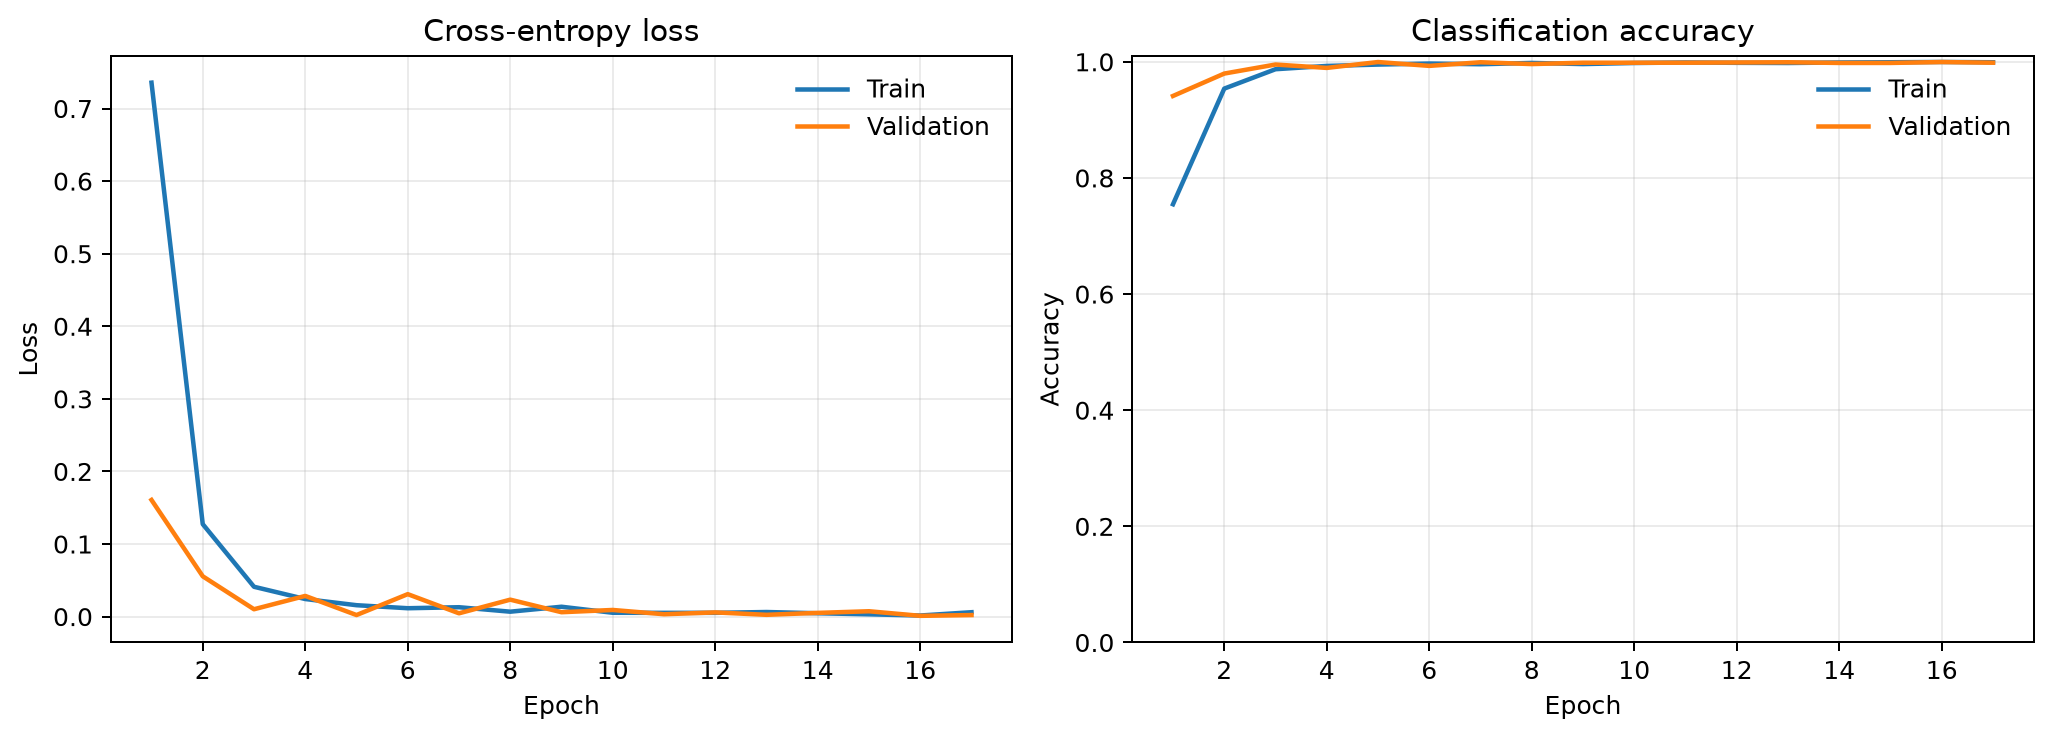

Sigmoid


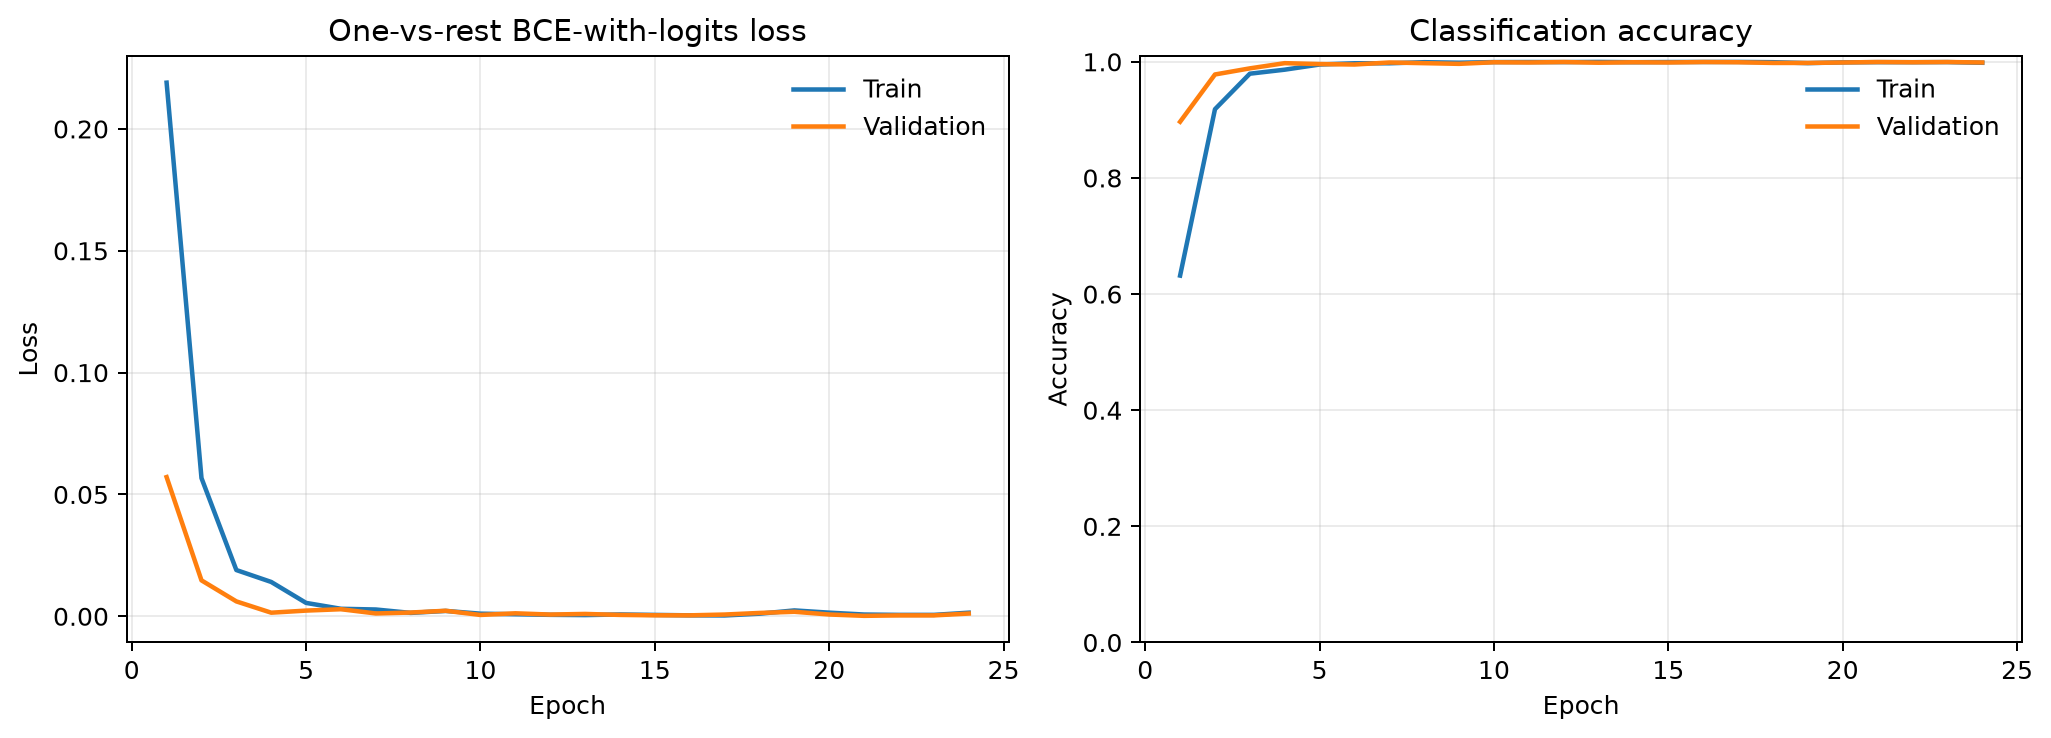

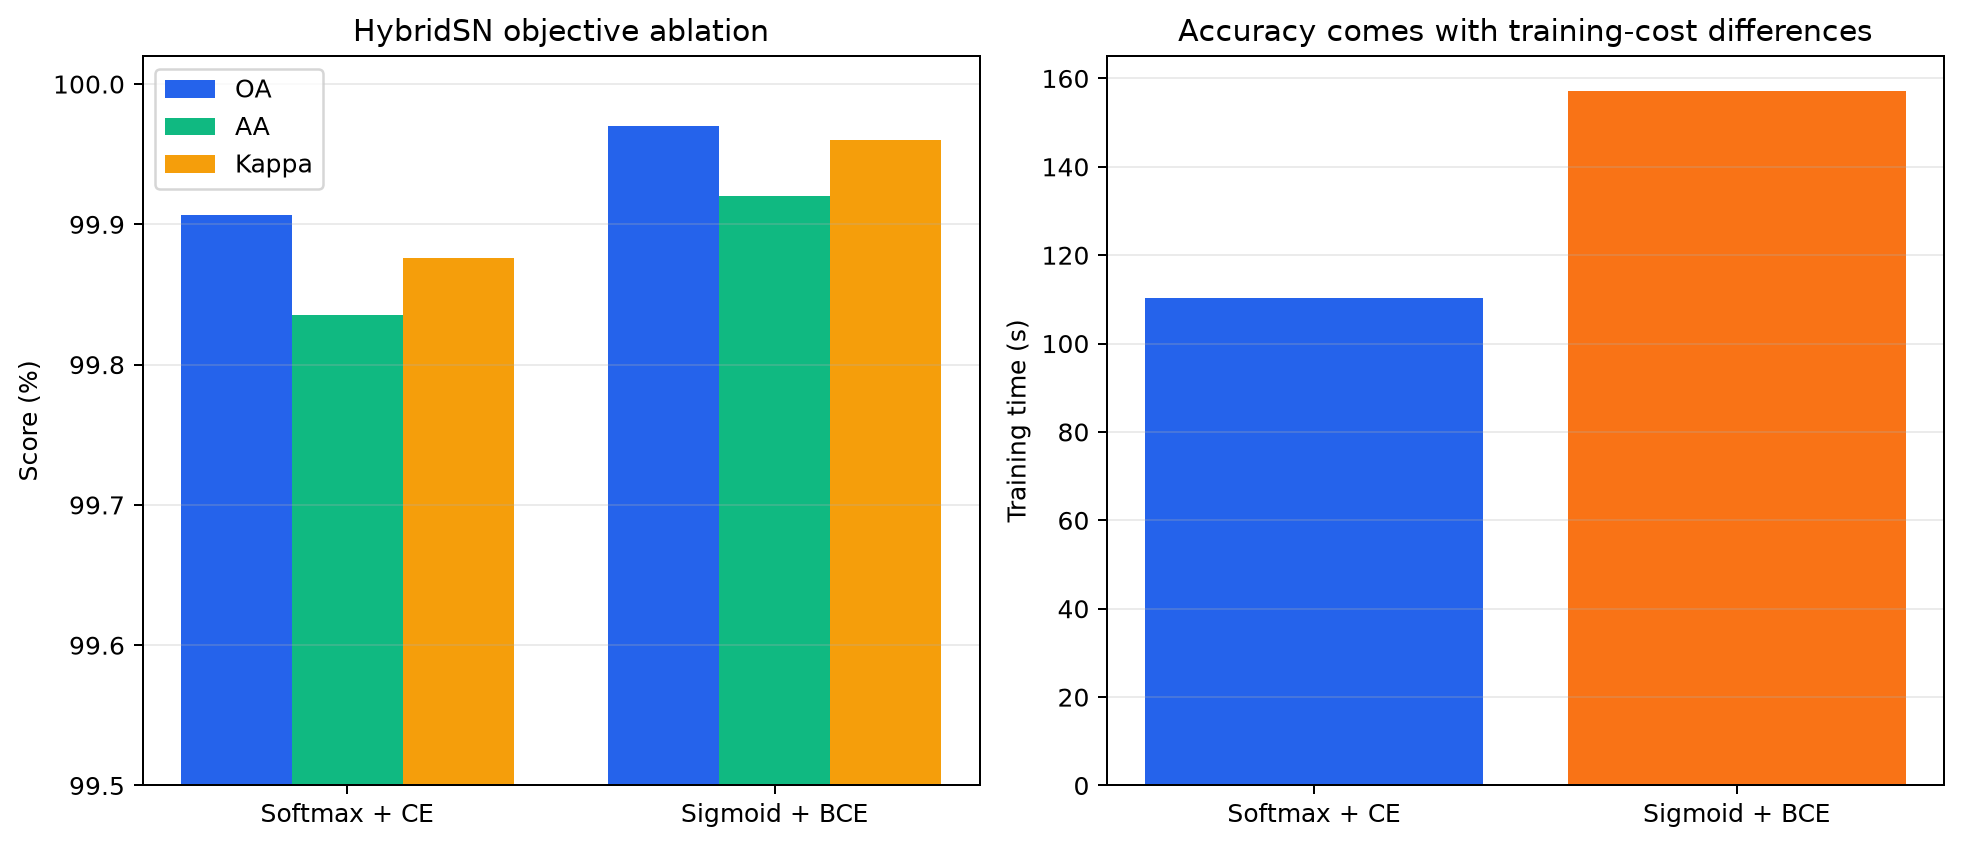

In [7]:
for name, output in (("Softmax", SOFTMAX_OUT), ("Sigmoid", SIGMOID_OUT)):
    print(name)
    display(Image(filename=str(output / "learning_curves.png"), width=900))
display(Image(filename=str(PROJECT_ROOT / "coursework/outputs/report_figures/hybridsn_objective_comparison.png"), width=900))


## 6. 测试指标、混淆矩阵、逐类准确率和分类图


Softmax baseline


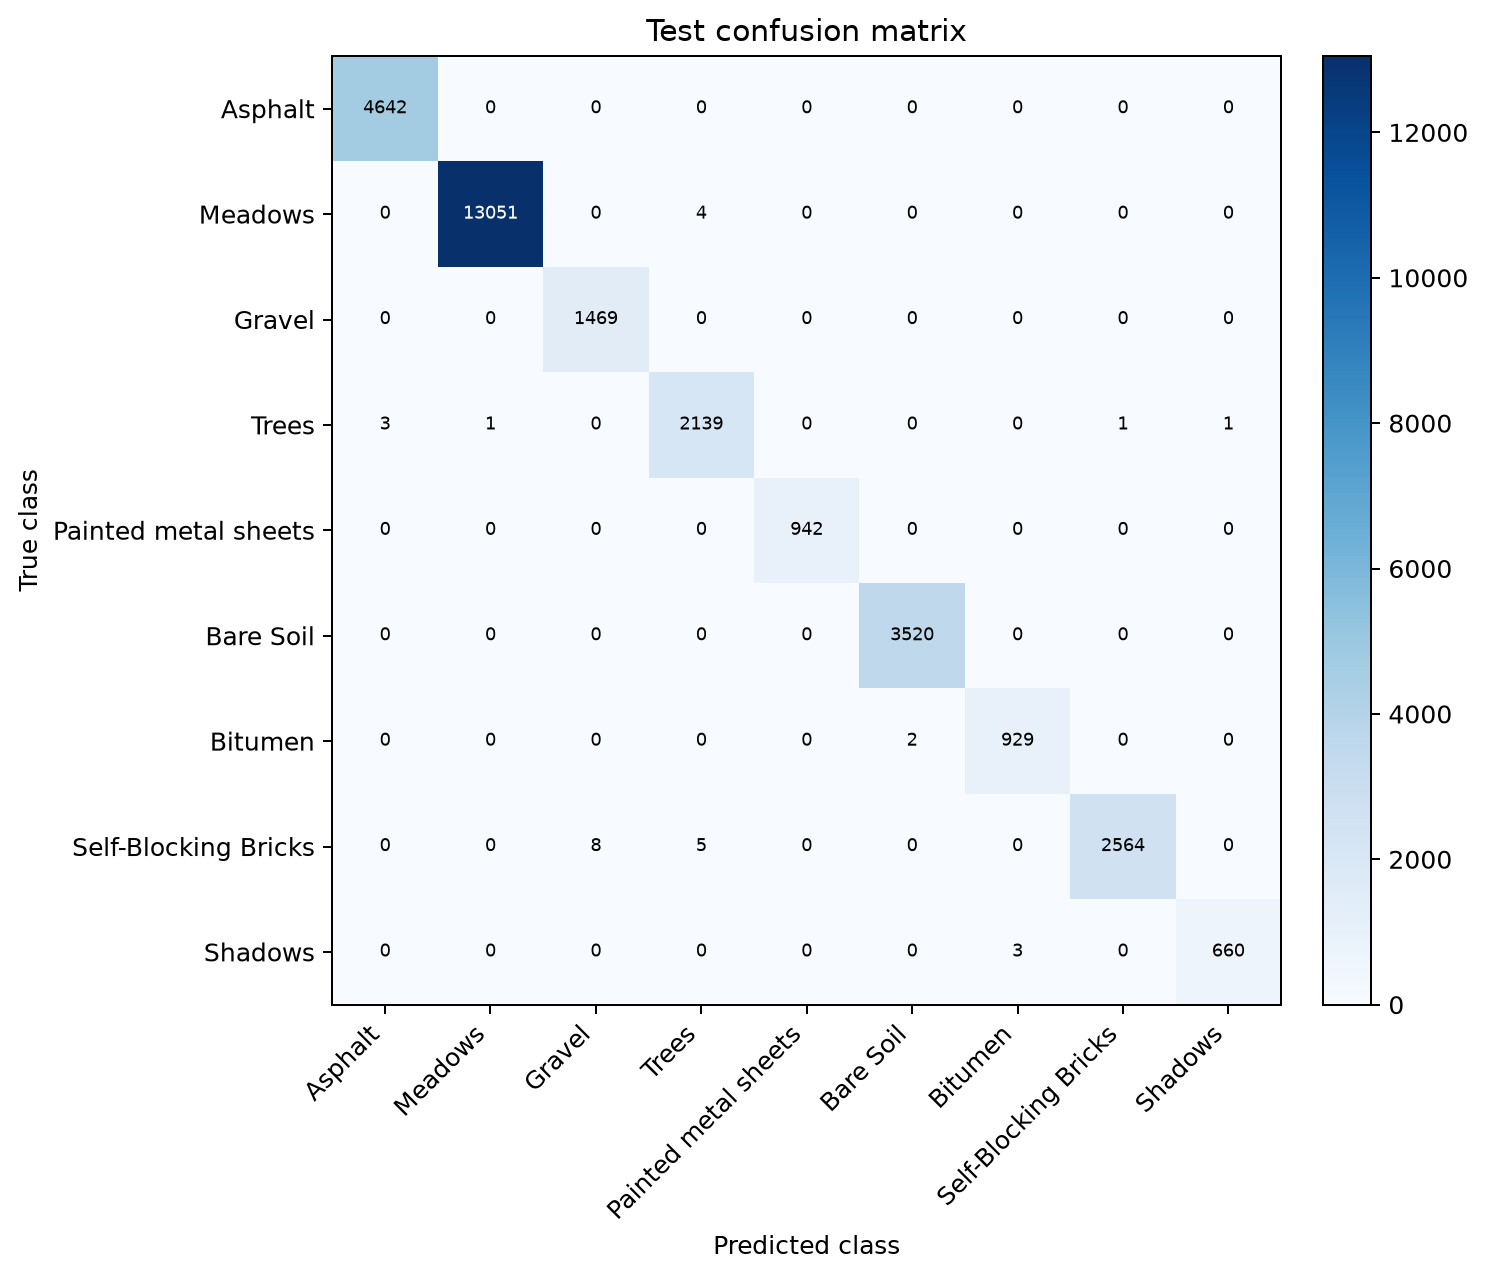

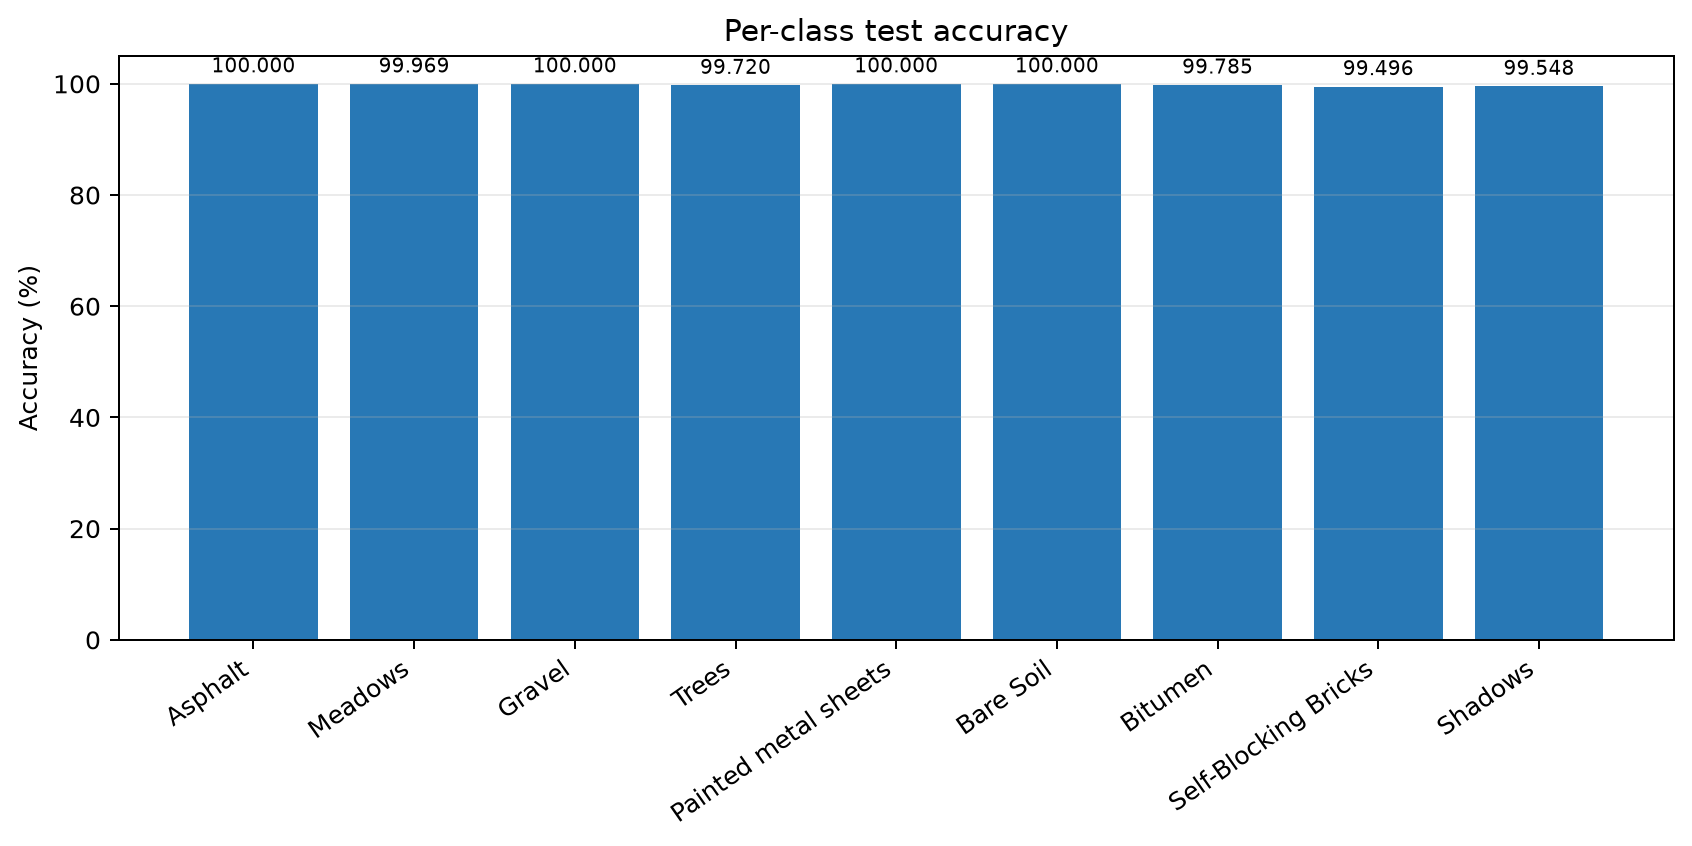

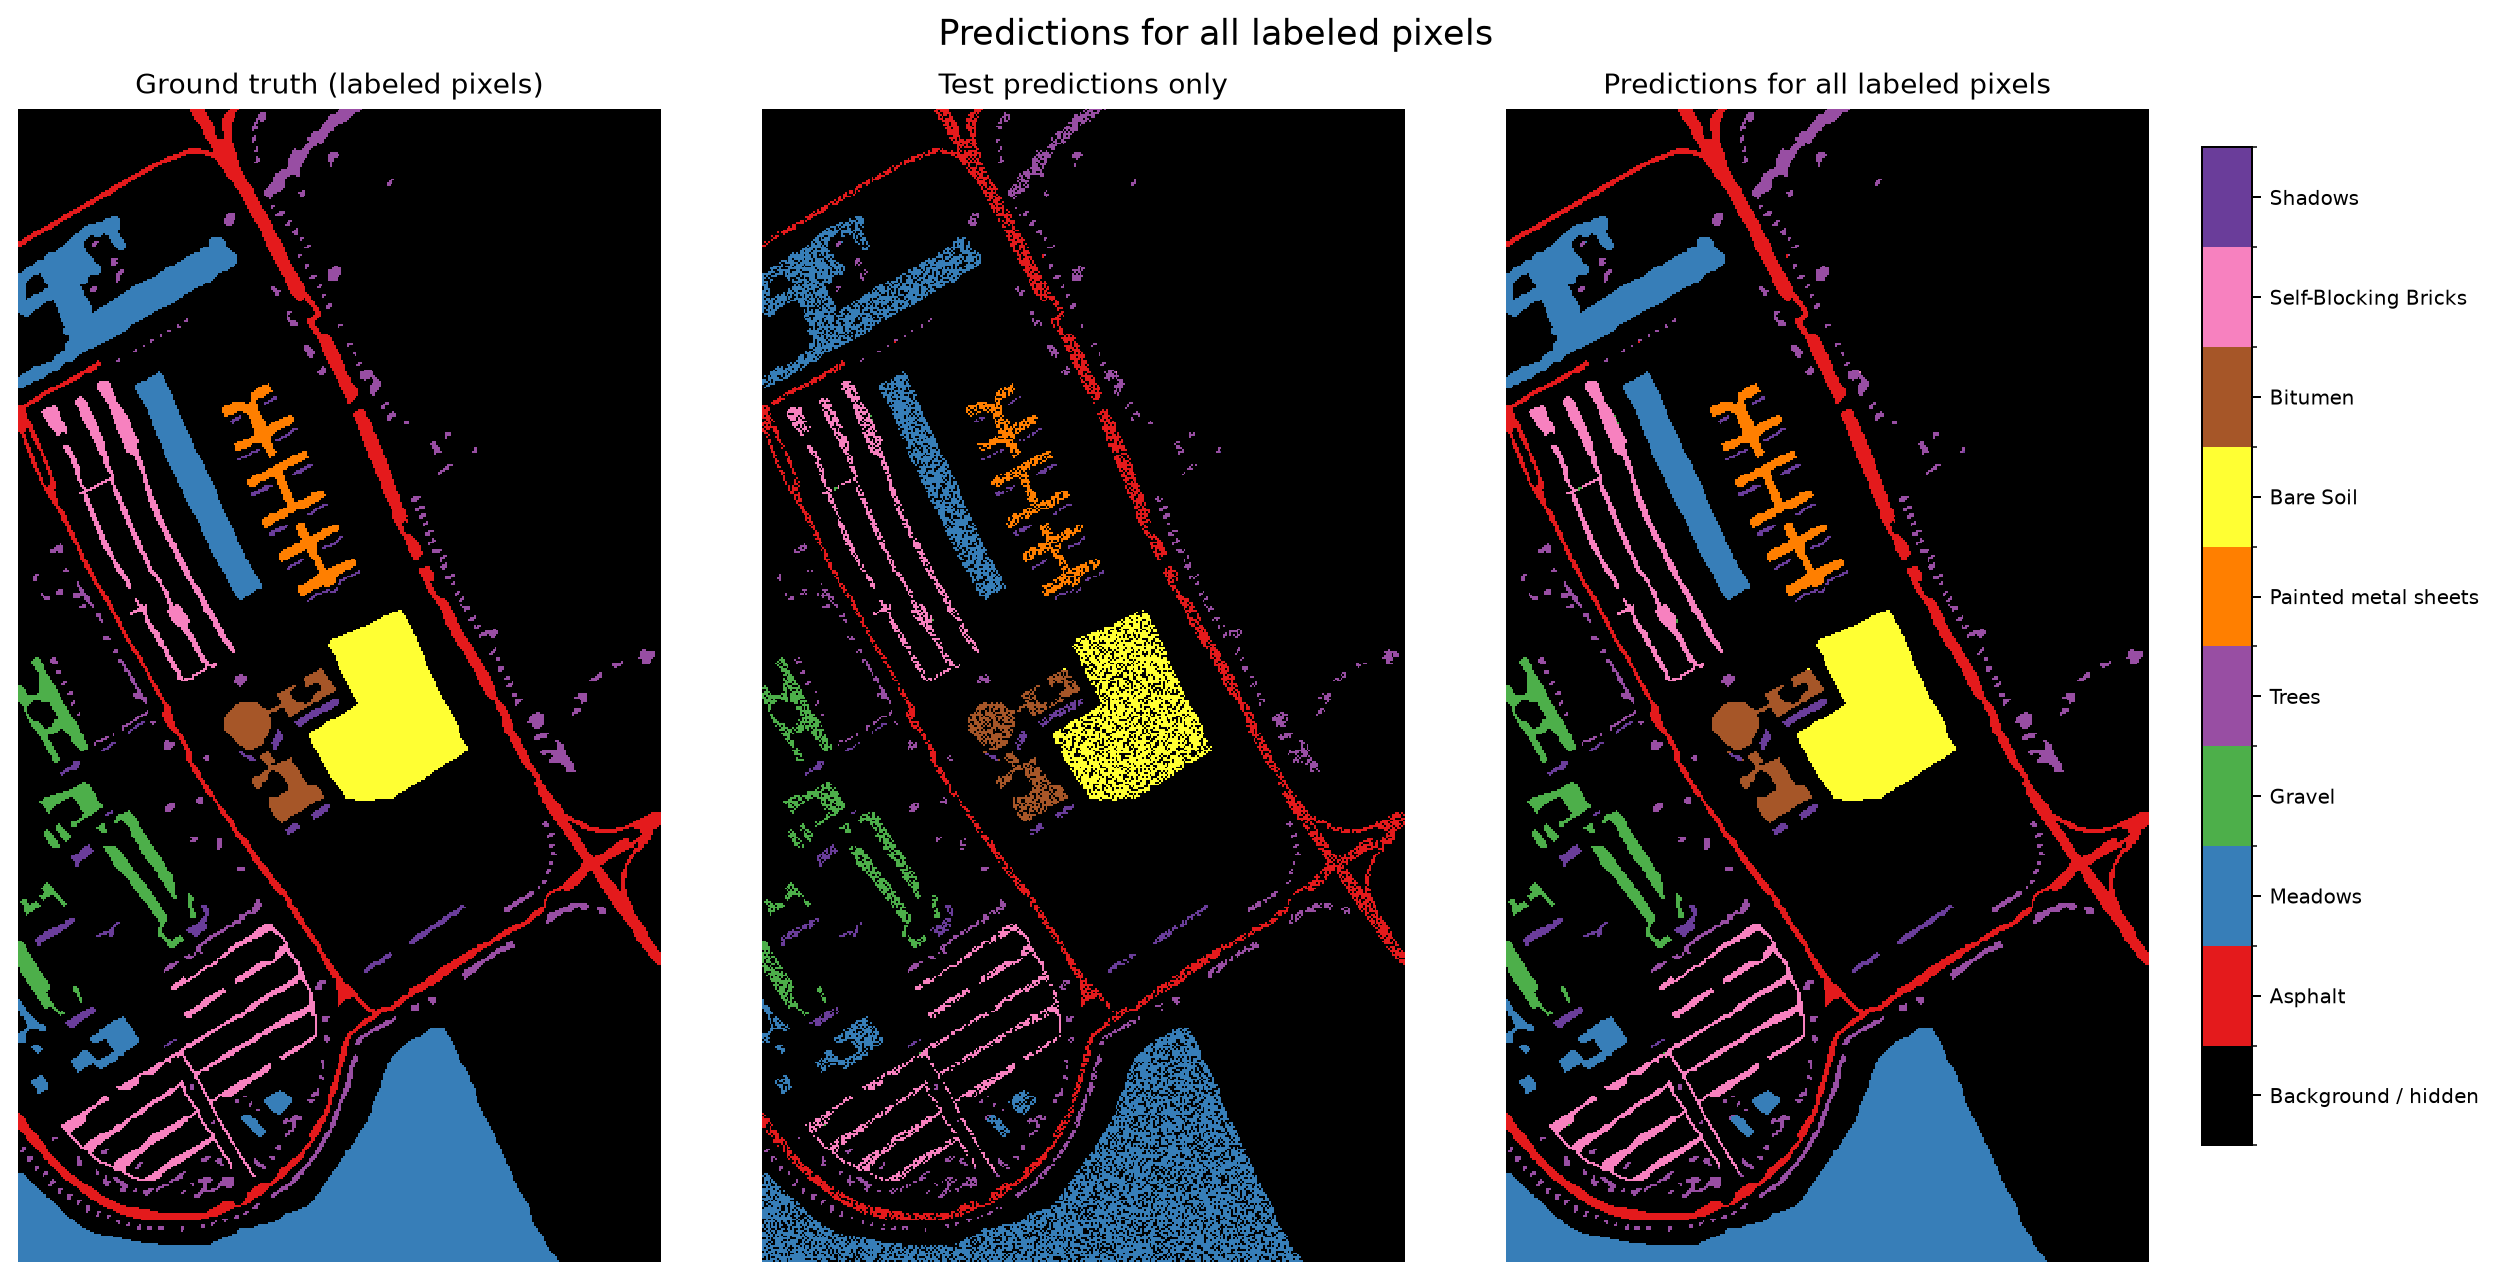

Sigmoid ablation


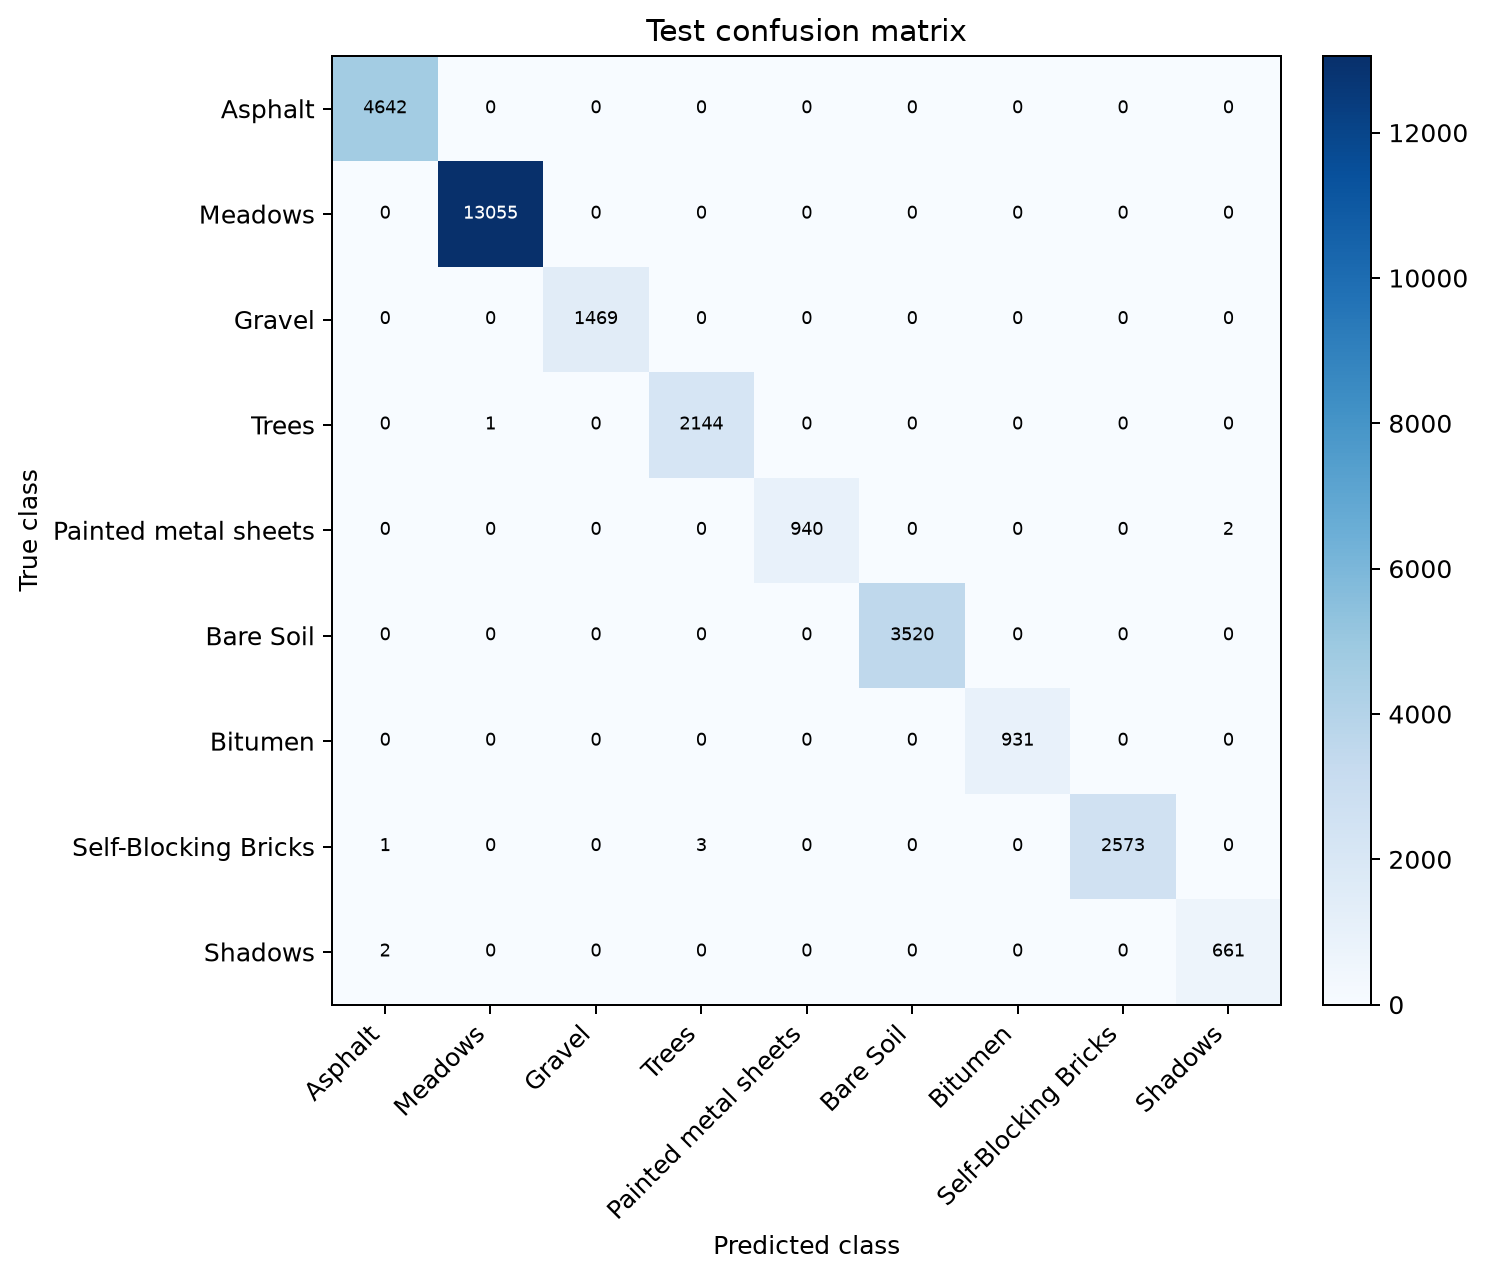

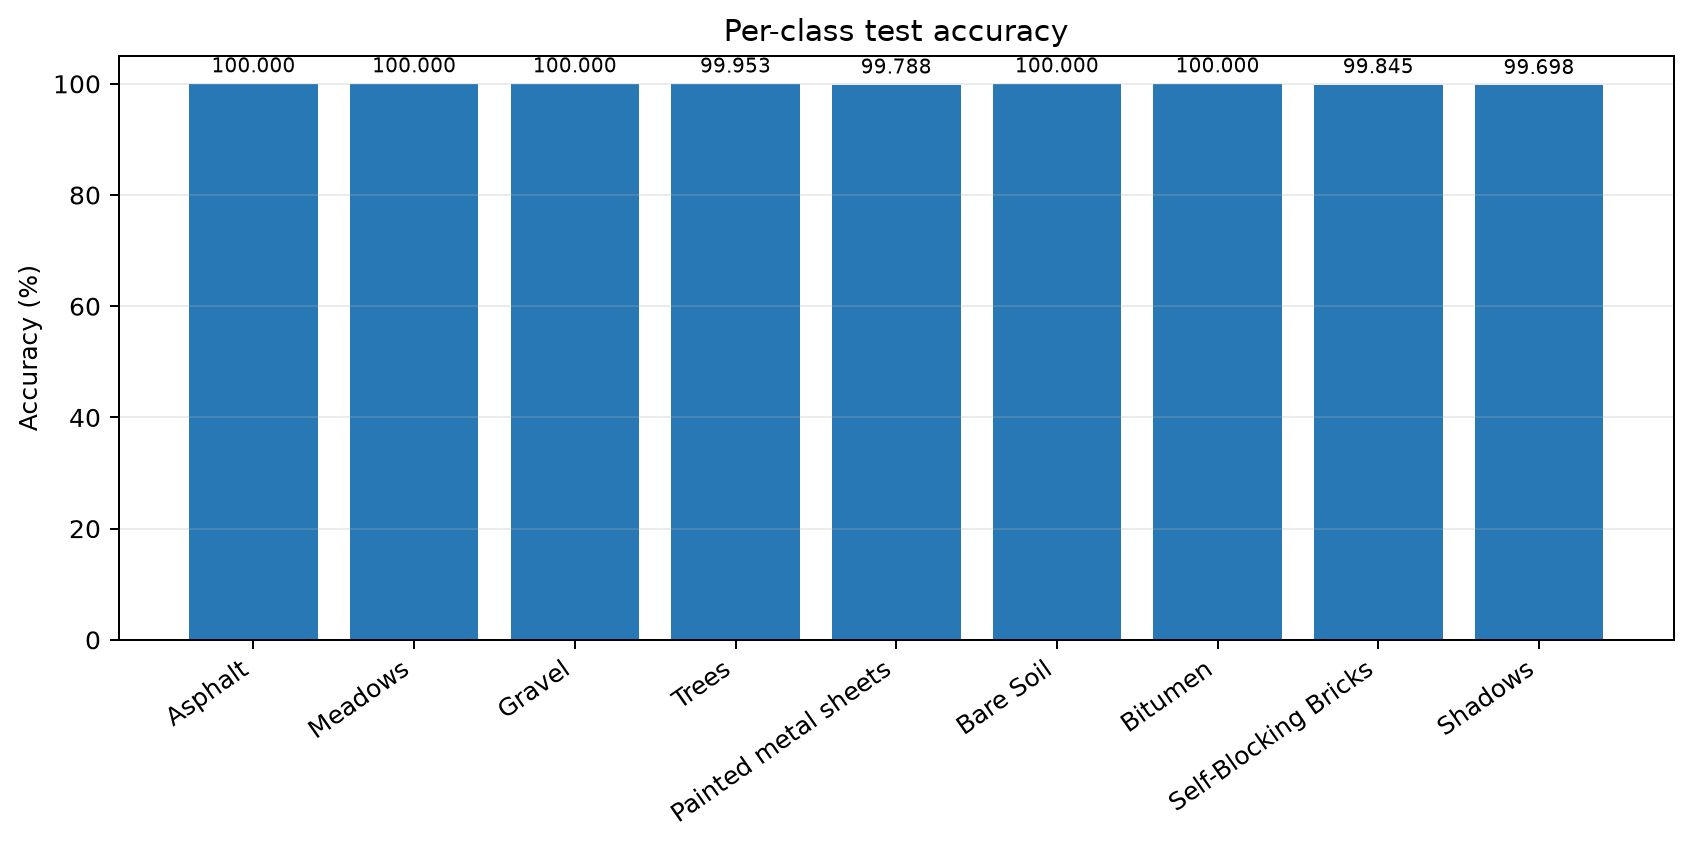

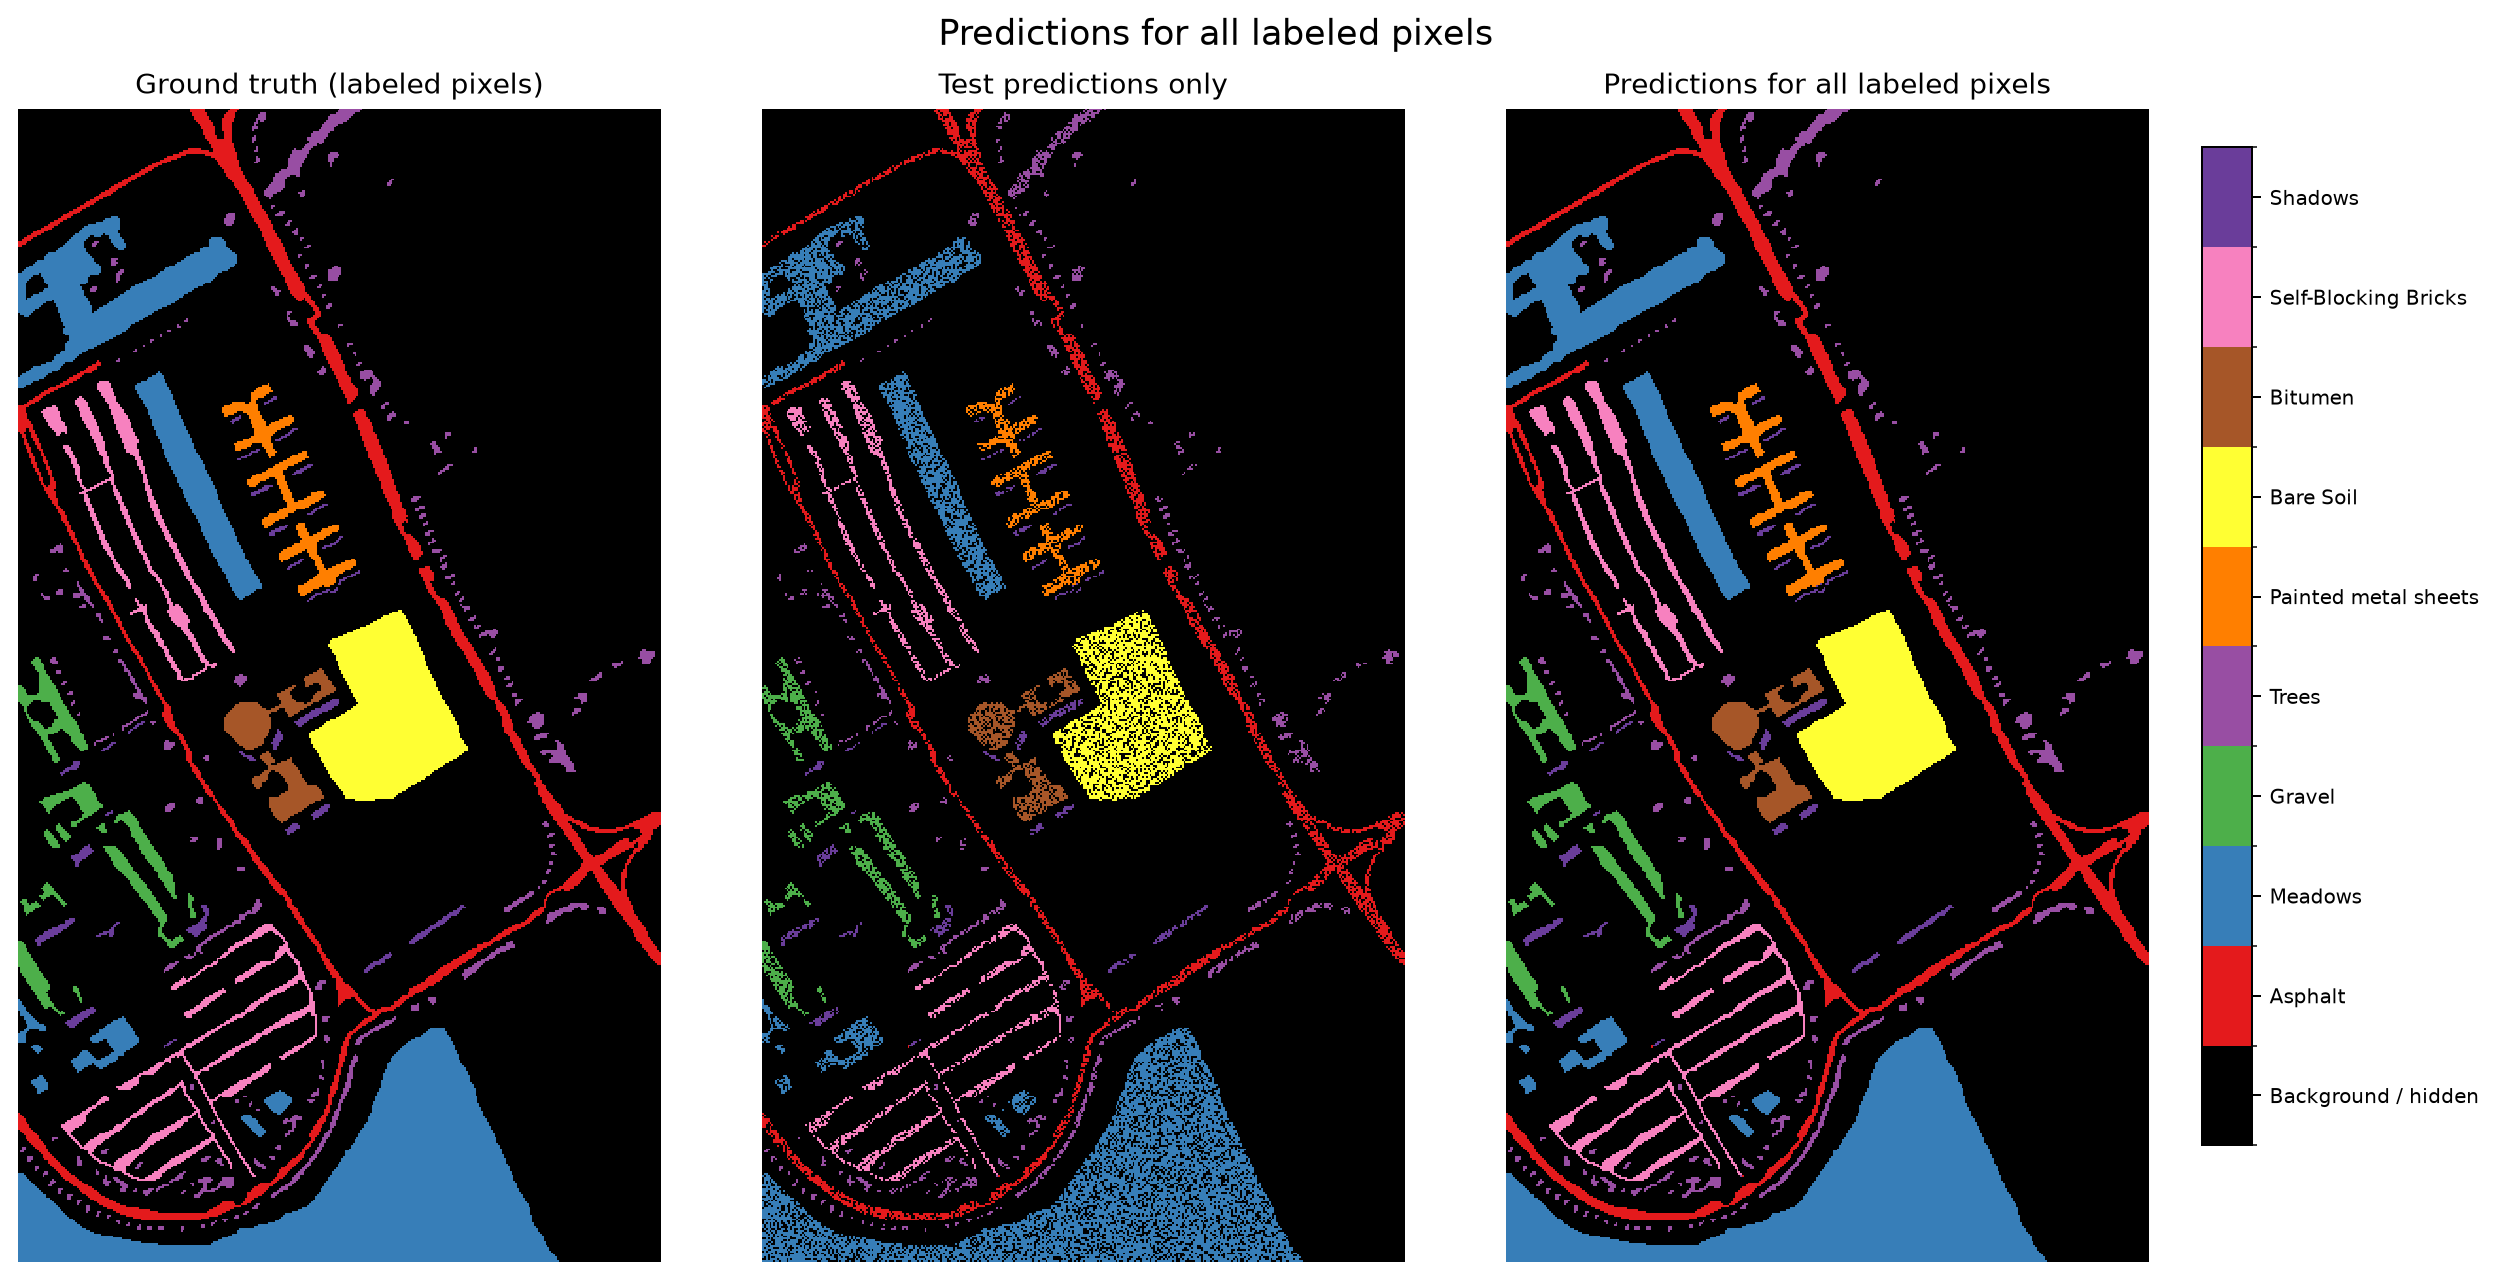

In [8]:
for title, output in (("Softmax baseline", SOFTMAX_OUT), ("Sigmoid ablation", SIGMOID_OUT)):
    print(title)
    display(Image(filename=str(output / "confusion_matrix.png"), width=650))
    display(Image(filename=str(output / "per_class_accuracy.png"), width=760))
    display(Image(filename=str(output / "classification_maps.png"), width=1100))


## 7. 重要有效性边界：随机像元划分的空间邻域重叠


In [9]:
audit = json.loads((SOFTMAX_OUT / "spatial_overlap_audit.json").read_text(encoding="utf-8"))
pd.DataFrame([
    {"measure": "任意训练中心落入测试 patch", **audit["any_training_center_in_query_patch"]},
    {"measure": "同类训练中心落入测试 patch", **audit["same_class_training_center_in_query_patch"]},
])


,measure,query_samples,with_at_least_one,fraction_with_at_least_one,minimum,median,mean,maximum
0,任意训练中心落入测试 patch,29944,29939,0.999833,0,73.0,80.557140,178
1,同类训练中心落入测试 patch,29944,29934,0.999666,0,71.0,77.096113,178


随机像元划分会让相邻训练/测试 patch 高度重叠，因此极高 OA 不能直接等价为对新场景的泛化能力。报告必须同时保留这一审计。建设性改进顺序：增加空间块划分或跨场景验证；做多 seed 重复并报告均值±标准差；再比较轻量化、BatchNorm、数据增强和注意力模块。
